In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
file_path = r"/content/Dataset for Data Analytics (1).xlsx"
df = pd.read_excel(file_path)

# Display basic info
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
# Check data types and missing values
print("DATA TYPES")
print(df.dtypes)
print("\n MISSING VALUES")
print(df.isnull().sum())
print("\nBASIC STATISTICS ")
df.describe()

DATA TYPES
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

 MISSING VALUES
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

BASIC STATISTICS 


,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [5]:
# Look at categorical columns
categorical_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource', 'CouponCode']

for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts().head(5))


=== Product ===
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Name: count, dtype: int64

=== PaymentMethod ===
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

=== OrderStatus ===
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

=== ReferralSource ===
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

=== CouponCode ===
CouponCode
FREESHIP    313
WINTER15    292
SAVE10      286
Name: count, dtype: int64


In [6]:
# Total revenue and basic stats
total_revenue = df['TotalPrice'].sum()
avg_order_value = df['TotalPrice'].mean()
total_orders = len(df)

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Average Order Value: ${avg_order_value:.2f}")
print(f"Total Orders: {total_orders}")
print(f"Unique Customers: {df['CustomerID'].nunique()}")

Total Revenue: $1,264,761.96
Average Order Value: $1053.97
Total Orders: 1200
Unique Customers: 1189


TOP 5 PRODUCTS BY REVENUE:
Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Name: TotalPrice, dtype: float64

BOTTOM 5 PRODUCTS BY REVENUE:
Product
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


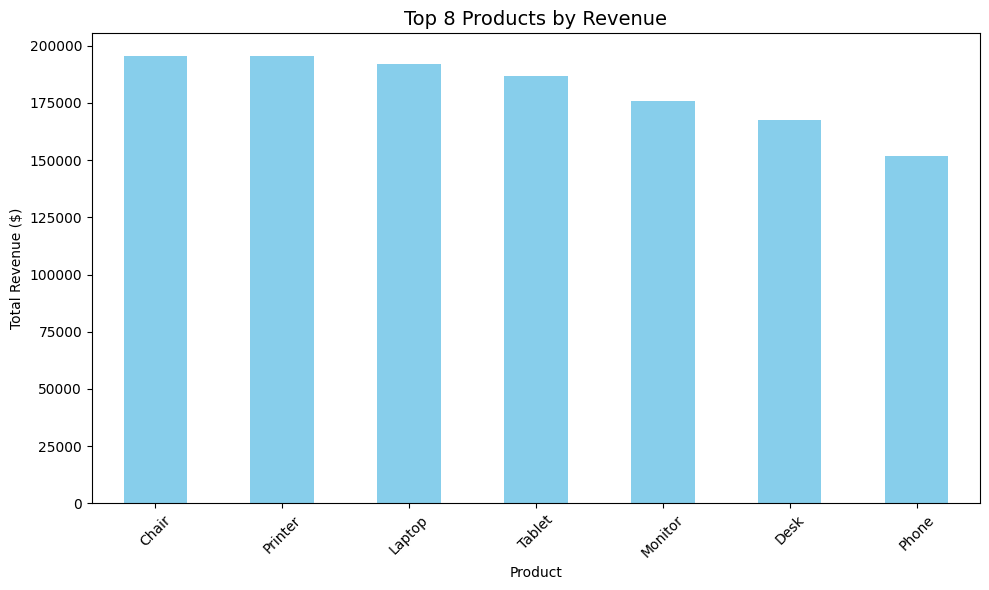

In [7]:
# Best selling products by revenue
product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
print("TOP 5 PRODUCTS BY REVENUE:")
print(product_revenue.head(5))
print("\nBOTTOM 5 PRODUCTS BY REVENUE:")
print(product_revenue.tail(5))

# Simple bar chart
plt.figure(figsize=(10, 6))
product_revenue.head(8).plot(kind='bar', color='skyblue')
plt.title('Top 8 Products by Revenue', fontsize=14)
plt.xlabel('Product')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ORDER STATUS COUNTS:
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

Completed Orders (Delivered + Shipped): 466
Cancelled/Returned Orders: 497


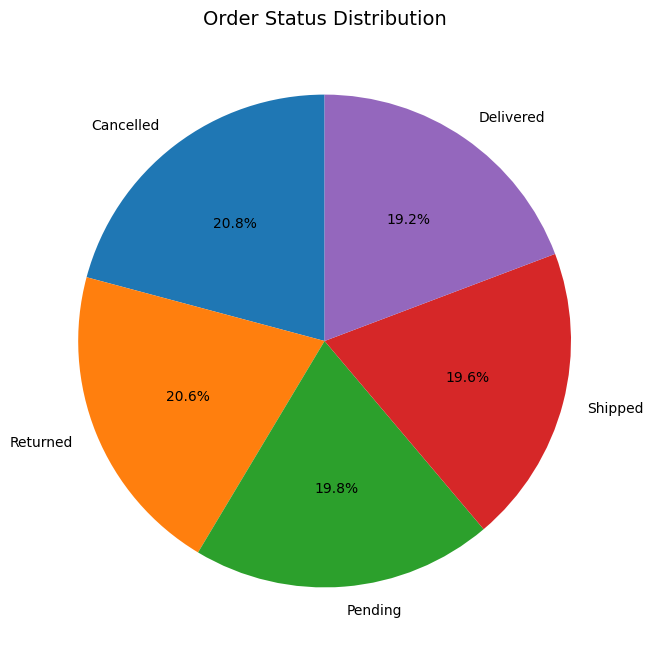

In [8]:
# Order status distribution
status_counts = df['OrderStatus'].value_counts()
print("ORDER STATUS COUNTS:")
print(status_counts)
print(f"\nCompleted Orders (Delivered + Shipped): {status_counts.get('Delivered', 0) + status_counts.get('Shipped', 0)}")
print(f"Cancelled/Returned Orders: {status_counts.get('Cancelled', 0) + status_counts.get('Returned', 0)}")

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Order Status Distribution', fontsize=14)
plt.show()

PAYMENT METHODS - Orders:
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

PAYMENT METHODS - Revenue:
PaymentMethod
Credit Card    263847.63
Online         262442.94
Cash           259786.29
Gift Card      246323.92
Debit Card     232361.18
Name: TotalPrice, dtype: float64


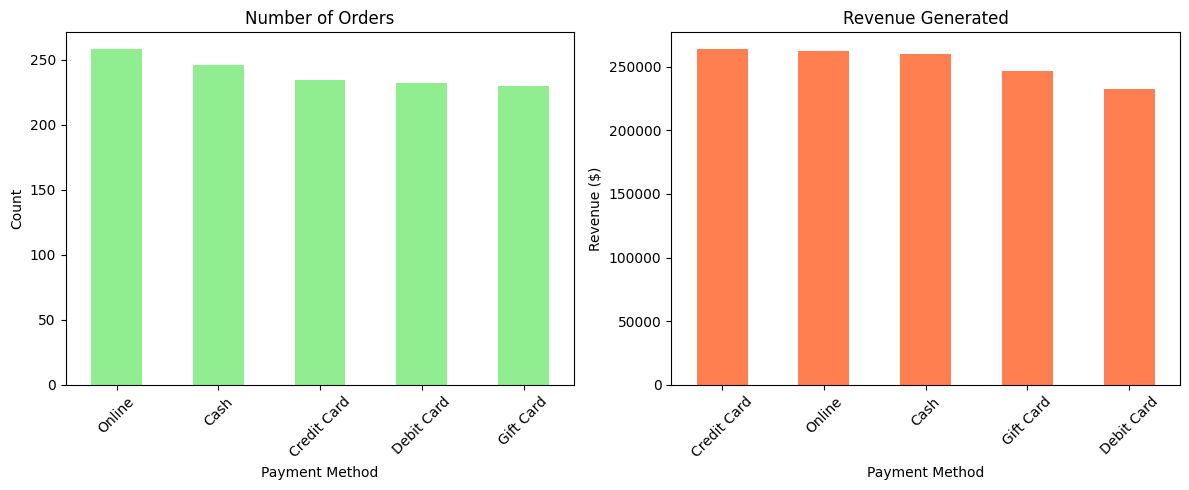

In [9]:
# Payment method popularity
payment_counts = df['PaymentMethod'].value_counts()
payment_revenue = df.groupby('PaymentMethod')['TotalPrice'].sum().sort_values(ascending=False)

print("PAYMENT METHODS - Orders:")
print(payment_counts)
print("\nPAYMENT METHODS - Revenue:")
print(payment_revenue)

# Side by side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
payment_counts.plot(kind='bar', ax=ax1, color='lightgreen')
ax1.set_title('Number of Orders')
ax1.set_xlabel('Payment Method')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

payment_revenue.plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('Revenue Generated')
ax2.set_xlabel('Payment Method')
ax2.set_ylabel('Revenue ($)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

ORDERS BY MONTH:
Month
April        113
August        79
December      87
February     106
January      106
July          87
June         147
March        128
May          120
November      76
October       78
September     73
dtype: int64


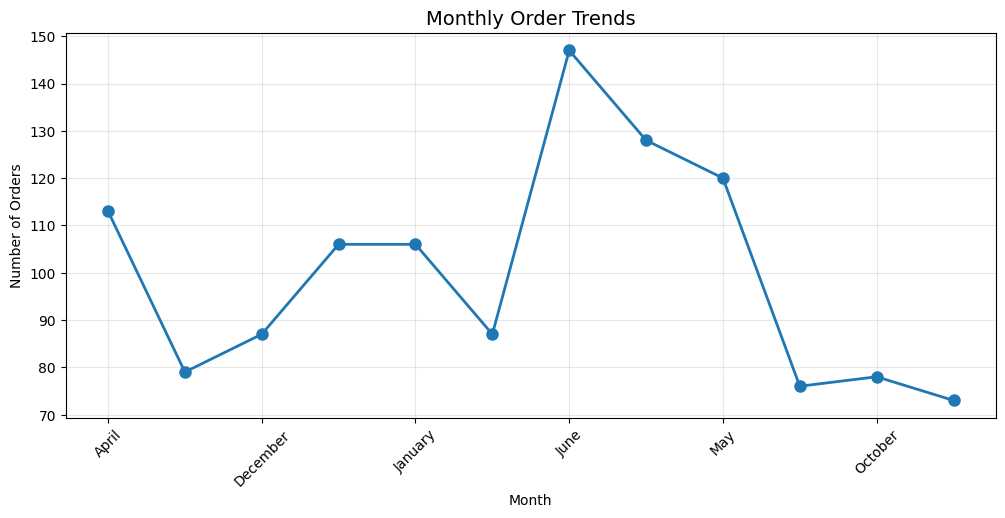

In [10]:
# Convert date if needed
df['Date'] = pd.to_datetime(df['Date'])

# Extract month
df['Month'] = df['Date'].dt.month_name()

# Orders by month
monthly_orders = df.groupby('Month').size()
print("ORDERS BY MONTH:")
print(monthly_orders)

# Line chart
plt.figure(figsize=(12, 5))
monthly_orders.plot(kind='line', marker='o', linewidth=2, markersize=8)
plt.title('Monthly Order Trends', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

CORRELATION MATRIX:
            Quantity  UnitPrice  TotalPrice
Quantity    1.000000   0.014553    0.615251
UnitPrice   0.014553   1.000000    0.717081
TotalPrice  0.615251   0.717081    1.000000


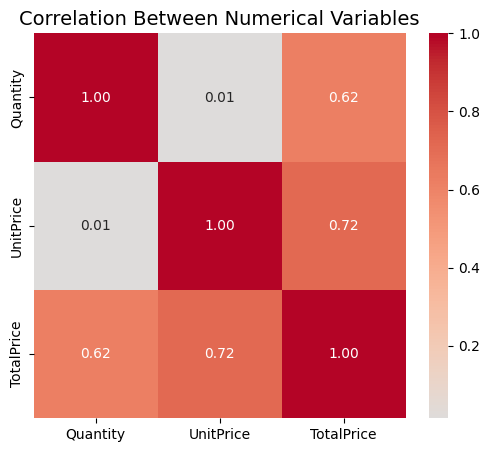

In [11]:
# Check correlation between numerical variables
numerical_cols = ['Quantity', 'UnitPrice', 'TotalPrice']
correlation = df[numerical_cols].corr()

print("CORRELATION MATRIX:")
print(correlation)

# Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Numerical Variables', fontsize=14)
plt.show()

QUANTITY STATISTICS:
Mean: 2.95
Median: 3.0
Min: 1
Max: 5


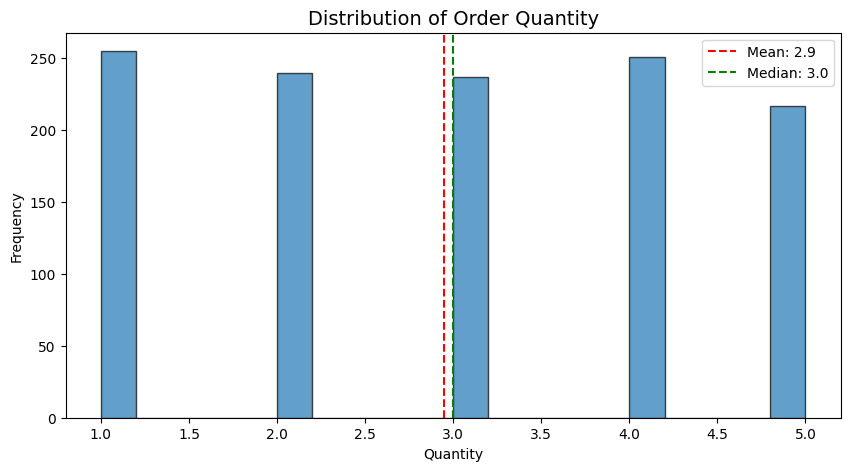

In [12]:
# How many items per order
print("QUANTITY STATISTICS:")
print(f"Mean: {df['Quantity'].mean():.2f}")
print(f"Median: {df['Quantity'].median()}")
print(f"Min: {df['Quantity'].min()}")
print(f"Max: {df['Quantity'].max()}")

# Histogram
plt.figure(figsize=(10, 5))
plt.hist(df['Quantity'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of Order Quantity', fontsize=14)
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.axvline(df['Quantity'].mean(), color='red', linestyle='--', label=f'Mean: {df["Quantity"].mean():.1f}')
plt.axvline(df['Quantity'].median(), color='green', linestyle='--', label=f'Median: {df["Quantity"].median()}')
plt.legend()
plt.show()

TOP 10 CUSTOMERS BY SPENDING:
1. Customer C38840: $5,723.23
2. Customer C57276: $3,456.40
3. Customer C67260: $3,390.80
4. Customer C13877: $3,384.90
5. Customer C18404: $3,370.20
6. Customer C16775: $3,353.75
7. Customer C65986: $3,352.40
8. Customer C47778: $3,334.00
9. Customer C59183: $3,322.55
10. Customer C25276: $3,313.90


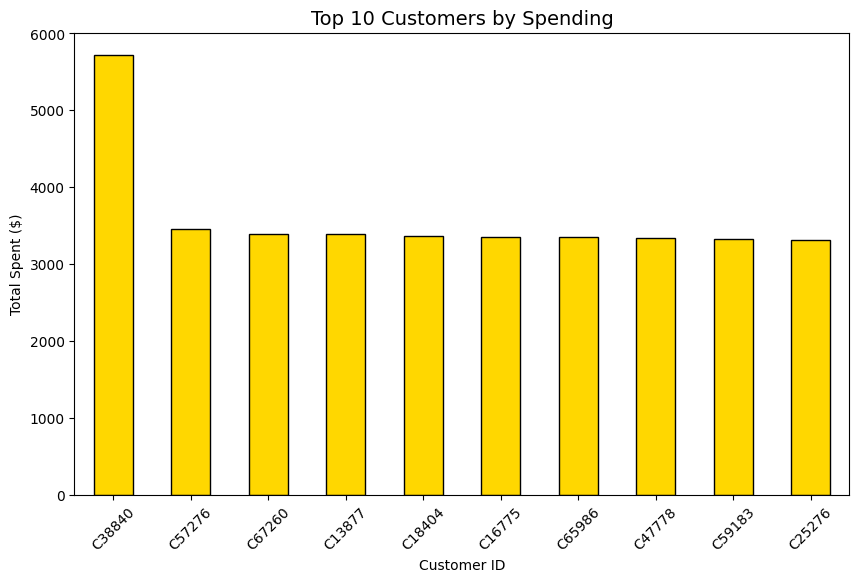

In [13]:
# Top spending customers
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

print("TOP 10 CUSTOMERS BY SPENDING:")
for i, (customer, amount) in enumerate(top_customers.items(), 1):
    print(f"{i}. Customer {customer}: ${amount:,.2f}")

# Bar chart
plt.figure(figsize=(10, 6))
top_customers.plot(kind='bar', color='gold', edgecolor='black')
plt.title('Top 10 Customers by Spending', fontsize=14)
plt.xlabel('Customer ID')
plt.ylabel('Total Spent ($)')
plt.xticks(rotation=45)
plt.show()